# 01 — EDA: Uzbek NER

Цель ноутбука — быстро понять, **что лежит в данных и какие риски важны для exact-span NER**.

Фокус:
- качество и баланс `ORG / NAME / GEO`;
- длина и составность сущностей;
- Latin / Cyrillic / mixed;
- апострофы и нестандартные символы;
- корректность `start/end`;
- overlap train/dev и доля unseen entities;
- автоматические выводы для следующих экспериментов.



In [2]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 180)

# Если ноутбук лежит в notebooks/, оставь ROOT = Path("..")
# Если запускаешь из корня проекта — поменяй на Path(".")
ROOT = Path(".")
DATA_DIR = ROOT / "data"

TRAIN_PATH = DATA_DIR / "train.jsonl"
DEV_PATH = DATA_DIR / "dev.jsonl"
MANIFEST_PATH = DATA_DIR / "dataset_manifest.json"

for p in [TRAIN_PATH, DEV_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Не найден {p}. Проверь ROOT/DATA_DIR и расположение train.jsonl/dev.jsonl."
        )

print("Train:", TRAIN_PATH.resolve())
print("Dev:  ", DEV_PATH.resolve())


Train: /Users/vladislav/Documents/multiscript-uzbek-ner/data/train.jsonl
Dev:   /Users/vladislav/Documents/multiscript-uzbek-ner/data/dev.jsonl


## 1. Загрузка и проверка схемы



In [3]:
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                raise ValueError(f"Некорректный JSON в {path}, строка {i}: {e}")
    return rows

train_raw = read_jsonl(TRAIN_PATH)
dev_raw = read_jsonl(DEV_PATH)

print(f"train rows: {len(train_raw):,}")
print(f"dev rows:   {len(dev_raw):,}")

print("\nПример train:")
display(train_raw[0])

if MANIFEST_PATH.exists():
    print("\nManifest:")
    with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
        display(json.load(f))
else:
    print("\ndataset_manifest.json не найден — это не блокирует EDA.")


train rows: 13,000
dev rows:   1,500

Пример train:


{'hash': '0000e9b18d8c83339a9ecd4c8aa1000020260228',
 'text': 'Тошкент вилоятининг Бўка-Бекобод йўлида ИИБ ходими томонидан уриб юборилиб, Дўстлик каналига ташлангани айтилган 43 ёшли фуқаронинг жасади 80 кун ўтиб топилди. Марҳумнинг яқинлари маълум қилишича, жасад 28-февраль куни соат 10:30 ларда Дўстлик каналидан, сув оқимининг қуйи қисмидан аниқланган. У қум остида қолиб кетган бўлган. Қариндошларининг айтишича, мурда ИИБ ходими ва унинг турмуш ўртоғи томонидан сувга ташланган жойдан тахминан 4 километр узоқликдаги жинғил тагидан чиққан. Аввалроқ вилоят ҳокимлиги кўмагида каналнинг бир қисми вақтинча ёпилиб, сув босими камайтирилган ва ФВВ қутқарувчилари, маҳалла аҳли ҳамда қариндошлардан иборат 150 нафарга яқин киши қидирув ишларини олиб борганди, бироқ ўшанда жасад топилмаганди. Эслатиб ўтамиз, ҳодиса 2025-йил 11-декабрь куни содир бўлган. Дастлабки маълумотларга кўра, Нехиа-3 бошқарган ИИБ ходими пиёдани уриб юборган, сўнг воқеани яшириш мақсадида уни бошқа автомобилга ўтказиб, в


Manifest:


{'schema_version': 1,
 'task': 'exact-span named entity recognition',
 'schema': {'record_fields': ['hash', 'text', 'entities'],
  'entity_fields': ['label', 'start', 'end'],
  'labels': ['GEO', 'NAME', 'ORG'],
  'offsets': 'zero-based character offsets; end is exclusive; offsets refer to text'},
 'documentation': {'path': 'README.md',
  'sha256': '1a951688eb07dc0ab37b8b13aa3f281d966a1af5eb01a944bc22820c328c55d7'},
 'assets': [{'path': 'API.md',
   'sha256': '06e92596da4c553b364aaae1afef22992d2b9bbfe97329cddbfc57a04fe6f04c'},
  {'path': 'LABELING_GUIDE.md',
   'sha256': 'd41f8b36fd0bec89833756f7f3ef7ed1d3534460cb7e2f0cd803f83dc5f5a6b8'},
  {'path': 'README.md',
   'sha256': '1a951688eb07dc0ab37b8b13aa3f281d966a1af5eb01a944bc22820c328c55d7'},
  {'path': 'baseline/__init__.py',
   'sha256': '4ddc36818573dd0dea0e0d9a84865171d9fc93846170f1b4bd871c659aef688a'},
  {'path': 'baseline/common.py',
   'sha256': '4276bbde702a7f4489f1af8664ce56c4adde14f0f8c10e35301f1d778917af92'},
  {'path': 'base

In [4]:
def infer_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    return None

sample = train_raw[0]

TEXT_KEY = infer_key(sample, ["text", "content", "sentence", "message"])
ENTITIES_KEY = infer_key(sample, ["entities", "spans", "labels", "annotations"])

print("Detected TEXT_KEY    =", TEXT_KEY)
print("Detected ENTITIES_KEY=", ENTITIES_KEY)

if TEXT_KEY is None or ENTITIES_KEY is None:
    raise KeyError(
        "Автоопределение схемы не сработало. "
        "Посмотри пример записи выше и вручную задай TEXT_KEY и ENTITIES_KEY в этой ячейке."
    )

first_entities = sample.get(ENTITIES_KEY, [])
print("\nПример сущности:")
display(first_entities[0] if first_entities else "В первой записи нет сущностей")


Detected TEXT_KEY    = text
Detected ENTITIES_KEY= entities

Пример сущности:


{'label': 'GEO', 'start': 0, 'end': 19}

In [5]:
# При необходимости поправь кандидаты под реальную схему одной сущности
def infer_entity_keys(entity):
    if not entity:
        return None, None, None, None
    start_key = infer_key(entity, ["start", "start_char", "begin", "offset_start"])
    end_key   = infer_key(entity, ["end", "end_char", "stop", "offset_end"])
    type_key  = infer_key(entity, ["type", "label", "entity_type", "tag"])
    text_key  = infer_key(entity, ["text", "value", "entity"])
    return start_key, end_key, type_key, text_key

probe_entity = next((e for r in train_raw for e in r.get(ENTITIES_KEY, []) if e), None)
START_KEY, END_KEY, TYPE_KEY, ENTITY_TEXT_KEY = infer_entity_keys(probe_entity)

print("START_KEY      =", START_KEY)
print("END_KEY        =", END_KEY)
print("TYPE_KEY       =", TYPE_KEY)
print("ENTITY_TEXT_KEY=", ENTITY_TEXT_KEY)

if None in [START_KEY, END_KEY, TYPE_KEY]:
    raise KeyError(
        "Не удалось определить поля start/end/type. "
        "Посмотри формат сущности выше и задай START_KEY/END_KEY/TYPE_KEY вручную."
    )


START_KEY      = start
END_KEY        = end
TYPE_KEY       = label
ENTITY_TEXT_KEY= None


## 2. Нормализация в две таблицы

Получаем:
- `docs` — один ряд = один текст;
- `ents` — один ряд = одна сущность.

Это упростит все следующие проверки.


In [6]:
def normalize_split(rows, split):
    docs = []
    ents = []

    for idx, r in enumerate(rows):
        text = r.get(TEXT_KEY, "")
        doc_id = r.get("id", r.get("text_id", r.get("uid", f"{split}_{idx}")))
        entities = r.get(ENTITIES_KEY, []) or []

        docs.append({
            "split": split,
            "doc_id": doc_id,
            "text": text,
            "n_chars": len(text),
            "n_entities": len(entities),
        })

        for j, e in enumerate(entities):
            start = e.get(START_KEY)
            end = e.get(END_KEY)
            label = e.get(TYPE_KEY)
            entity_text = e.get(ENTITY_TEXT_KEY) if ENTITY_TEXT_KEY else None

            span_text = None
            if isinstance(start, int) and isinstance(end, int) and 0 <= start <= end <= len(text):
                span_text = text[start:end]

            ents.append({
                "split": split,
                "doc_id": doc_id,
                "entity_idx": j,
                "label": label,
                "start": start,
                "end": end,
                "entity_text_annot": entity_text,
                "entity_text_span": span_text,
                "span_len_chars": (end - start) if isinstance(start, int) and isinstance(end, int) else np.nan,
                "span_len_words": len(span_text.split()) if isinstance(span_text, str) and span_text else 0,
            })

    return pd.DataFrame(docs), pd.DataFrame(ents)

train_docs, train_ents = normalize_split(train_raw, "train")
dev_docs, dev_ents = normalize_split(dev_raw, "dev")

docs = pd.concat([train_docs, dev_docs], ignore_index=True)
ents = pd.concat([train_ents, dev_ents], ignore_index=True)

display(docs.head())
display(ents.head())


,split,doc_id,text,n_chars,n_entities
0,train,train_0,"Тошкент вилоятининг Бўка-Бекобод йўлида ИИБ ходими томонидан уриб юборилиб, Дўстлик каналига ташлангани айтилган 43 ёшли фуқаронинг жасади 80 кун ўтиб топилди. Марҳумнинг яқинл...",1057,10
1,train,train_1,бу холатга йиг'лаш керак,24,0
2,train,train_2,Бошлаган ишларингизга оллохим барака берсин сиздай сахий тадбиркорлар купайсин,78,0
3,train,train_3,Худойим укиган дуволарингизги худойим Кабул этсун Омин Омин Омин,64,0
4,train,train_4,Alloh beraman desa xech gap emas.Xarakat bzdan Natijasi Allohdan major.jizzax,77,0


,split,doc_id,entity_idx,label,start,end,entity_text_annot,entity_text_span,span_len_chars,span_len_words
0,train,train_0,0,GEO,0,19,None,Тошкент вилоятининг,19,2
1,train,train_0,1,GEO,20,39,None,Бўка-Бекобод йўлида,19,2
2,train,train_0,2,ORG,40,43,None,ИИБ,3,1
3,train,train_0,3,GEO,76,92,None,Дўстлик каналига,16,2
4,train,train_0,4,GEO,236,253,None,Дўстлик каналидан,17,2


## 3. Базовый профиль датасета

На что смотрим:
- размер train/dev;
- число сущностей;
- доля текстов без сущностей;
- длина текстов;
- среднее число сущностей на сообщение.

Если dev сильно отличается от train, validation может отражать не только качество модели, но и **distribution shift**.


In [7]:
overview = (
    docs.groupby("split")
    .agg(
        texts=("doc_id", "count"),
        avg_chars=("n_chars", "mean"),
        median_chars=("n_chars", "median"),
        avg_entities=("n_entities", "mean"),
        texts_without_entities=("n_entities", lambda s: int((s == 0).sum())),
    )
)

entity_counts = ents.groupby("split").size().rename("entities")
overview = overview.join(entity_counts)
overview["share_without_entities"] = (
    overview["texts_without_entities"] / overview["texts"]
)

display(overview.round(3))


,texts,avg_chars,median_chars,avg_entities,texts_without_entities,entities,share_without_entities
split,,,,,,,
dev,1500,474.087,170.5,5.132,275,7698,0.183
train,13000,497.439,151.0,5.083,2386,66083,0.184


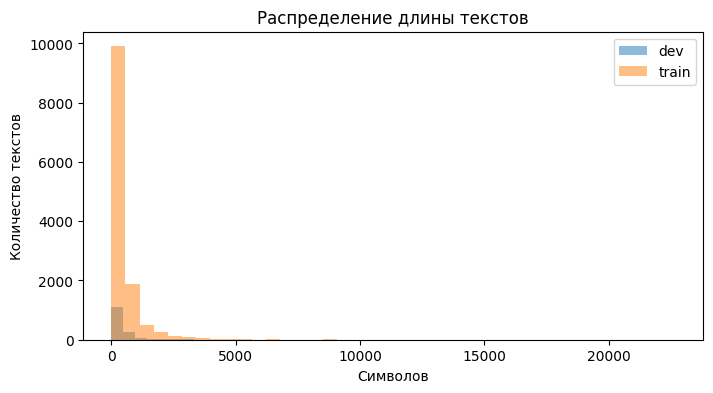

split,dev,train
0.50,170.0,151.0
0.90,999.0,1089.0
0.95,1719.0,1864.0
0.99,4252.0,4854.0
1.00,18975.0,22668.0


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for split, g in docs.groupby("split"):
    ax.hist(g["n_chars"], bins=40, alpha=0.5, label=split)
ax.set_title("Распределение длины текстов")
ax.set_xlabel("Символов")
ax.set_ylabel("Количество текстов")
ax.legend()
plt.show()

display(
    docs.groupby("split")["n_chars"]
    .quantile([0.5, 0.9, 0.95, 0.99, 1.0])
    .unstack(0)
    .round(0)
)


## 4. Баланс `ORG / NAME / GEO`

Ключевой вопрос: нет ли класса, который сильно недопредставлен.  
Для exact-span micro-F1 большой класс сильнее влияет на итоговый score, но слабый F1 по редкому классу всё равно важен для бизнес-ценности.


,split,label,count,share
0,dev,GEO,2720,0.353339
2,dev,ORG,2659,0.345414
1,dev,NAME,2319,0.301247
5,train,ORG,23420,0.354403
3,train,GEO,21445,0.324516
4,train,NAME,21218,0.321081


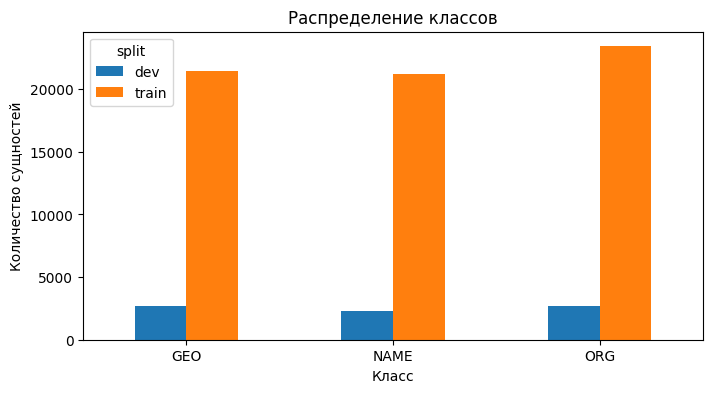

In [9]:
class_counts = (
    ents.groupby(["split", "label"])
    .size()
    .rename("count")
    .reset_index()
)

class_counts["share"] = class_counts.groupby("split")["count"].transform(lambda s: s / s.sum())
display(class_counts.sort_values(["split", "count"], ascending=[True, False]))

pivot = class_counts.pivot(index="label", columns="split", values="count").fillna(0)
pivot.plot(kind="bar", figsize=(8, 4))
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество сущностей")
plt.xticks(rotation=0)
plt.show()


## 5. Длина и составность сущностей

Для нашего кейса особенно важны **длинные ORG/GEO**: чем больше слов в span, тем выше вероятность ошибки границ.


In [10]:
entity_len_stats = (
    ents.groupby(["split", "label"])
    .agg(
        n=("entity_idx", "count"),
        median_chars=("span_len_chars", "median"),
        p90_chars=("span_len_chars", lambda s: s.quantile(0.9)),
        median_words=("span_len_words", "median"),
        p90_words=("span_len_words", lambda s: s.quantile(0.9)),
        multiword_share=("span_len_words", lambda s: (s > 1).mean()),
    )
    .round(3)
)

display(entity_len_stats)


n  median_chars  p90_chars  median_words  p90_words  \
split label                                                            
dev   GEO     2720           9.0       17.0           1.0        2.0   
      NAME    2319          10.0       18.0           1.0        2.0   
      ORG     2659          10.0       31.0           1.0        3.0   
train GEO    21445          10.0       17.0           1.0        2.0   
      NAME   21218           8.0       17.0           1.0        2.0   
      ORG    23420           9.0       28.0           1.0        3.0   

             multiword_share  
split label                   
dev   GEO              0.240  
      NAME             0.480  
      ORG              0.489  
train GEO              0.253  
      NAME             0.402  
      ORG              0.457

In [11]:
longest = (
    ents.dropna(subset=["entity_text_span"])
    .sort_values("span_len_chars", ascending=False)
    [["split", "label", "span_len_chars", "span_len_words", "entity_text_span"]]
    .head(25)
)
display(longest)


,split,label,span_len_chars,span_len_words,entity_text_span
48956,train,ORG,200,19,Qoraqalpog‘iston Respublikasi Jo‘qorg‘i Kengesining Mahalliy hokimiyat vakillik va fuqarolarning o‘zini-o‘zi boshqarish organlari hamda davlat organlarining ochiqligini ta’minl...
48969,train,ORG,198,19,Qaraqalpaqstan Respublikası Joqarǵı Keńesiniń Jergilikli hákimiyat wákillik hám puqaralardıń ózin-ózi basqarıw uyımları jáne mámleketlik uyımlardıń ashıq-aydınlıǵın támiyinlew ...
12420,train,ORG,159,16,Surxondaryo viloyati IIB Jamoat xavfsizligi xizmati Huquqbuzarliklar profilaktikasi boshqarmasi Voyaga yetmaganlarga ijtimoiy huquqiy yordam koʻrsatish markazi
45770,train,ORG,146,15,Oʻzbekiston Respublikasi Vazirlar Mahkamasi huzurida millatlararo munosabatlar va xorijiy mamlakatlar bilan doʻstona munosabatlar boʻyicha qoʻmita
40982,train,ORG,138,15,Xorijda mehnat faoliyatini amalga oshiruvchi shaxslarni qo‘llab-quvvatlash hamda ularning huquq va manfaatlarini himoya qilish jamg‘armasi
46120,train,ORG,136,15,Oʻzbekiston bosh prokuraturasi qoshidagi Pul yuvish va moliyaviy jinoyatlar boʻyicha departamentning Uchqoʻrgʻon tumani boʻyicha boʻlimi
17768,train,ORG,133,13,Oʻzbekiston Respublikasi Raqamli texnologiyalar vazirligi huzuridagi Sun'iy intellekt va raqamli iqtisodiyotni rivojlantirish markazi
47486,train,ORG,123,14,Respublika Ekologiya va iqlim o‘zgarishi milliy qo‘mitasi huzuridagi “Yashil loyiha” loyihalash instituti davlat muassasasi
20843,train,ORG,121,12,Самарқанд вилояти ҳокимининг молия-иқтисодиёт ва камбағалликни қисқартириш масалалари бўйича биринчи ўринбосари котибияти
40981,train,ORG,121,12,O'zbekiston Respublikasi Bandlik va kambag'allikni qisqartirish vazirligi huzuridagi Tashqi mehnat migratsiyasi agentligi


## 6. Latin / Cyrillic / mixed



,split,script,count,share
0,dev,cyrillic,268,0.178667
1,dev,latin,892,0.594667
2,dev,mixed,340,0.226667
3,train,cyrillic,2181,0.167769
4,train,latin,7840,0.603077
5,train,mixed,2978,0.229077
6,train,other,1,0.000077


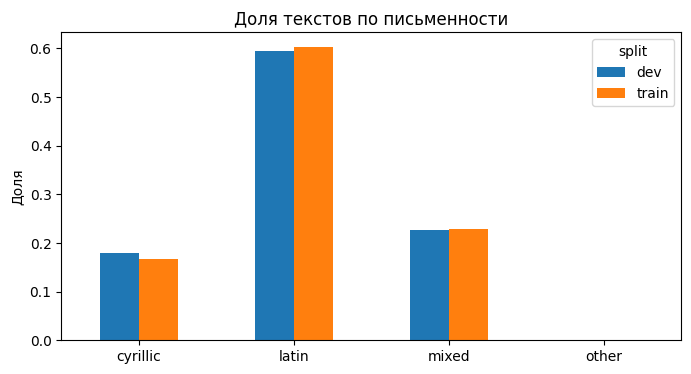

In [12]:
CYR_RE = re.compile(r"[А-Яа-яЁёЎўҚқҒғҲҳ]")
LAT_RE = re.compile(r"[A-Za-zʻʼ’`']")

def script_bucket(text):
    has_cyr = bool(CYR_RE.search(text))
    has_lat = bool(LAT_RE.search(text))
    if has_cyr and has_lat:
        return "mixed"
    if has_cyr:
        return "cyrillic"
    if has_lat:
        return "latin"
    return "other"

docs["script"] = docs["text"].map(script_bucket)

script_dist = (
    docs.groupby(["split", "script"])
    .size()
    .rename("count")
    .reset_index()
)
script_dist["share"] = script_dist.groupby("split")["count"].transform(lambda s: s / s.sum())

display(script_dist)

script_dist.pivot(index="script", columns="split", values="share").fillna(0).plot(
    kind="bar", figsize=(8, 4)
)
plt.title("Доля текстов по письменности")
plt.ylabel("Доля")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()


In [13]:
docs.loc[docs["script"] == "other", "text"].iloc[0]

'مەسعود بارزانی، سەرۆکی پارتی دیموکرات و سەلاحەددین بەهائەدین، ئەمینداری گشتیی یەكگرتووی ئیسلامی کۆبوونەوە. بارەگای بارزانی دەڵێت "لە دیدارەكەدا مامۆستا سەلاحەددین سوپاسی ڕۆڵی سەرۆك بارزانیی كرد بۆ پەرۆشی و هەوڵە بەردەوامەكانی بۆ پاراستنی گەلی كورد لە ڕۆژئاوا و ڕۆڵی كاریگەری لە پڕۆسەی ئاشتی لە توركیادا". دەشڵێت "سەرۆك بارزانی باسی لەوە كرد هەرێمی كوردستان لەپێناو نەهێشتنی كێشەكان و پاراستنی سەقامگیری، ئامادەیە لە هەر ڕۆڵێكی ئاشتیخوازانەدا بەشدار بێ كە لێی بخوازرێ".'

окак

## 7. Апострофы и нестандартные варианты

Для узбекской латиницы это потенциально важный источник tokenization noise:

`O'zbekiston`, `O‘zbekiston`, `Oʻzbekiston`, ``O`zbekiston``

Если вариантов много, стоит отдельно проверить **normalization + mapping offsets обратно в исходный текст**.


In [14]:
APOSTROPHES = ["'", "’", "ʻ", "ʼ", "`", "‘"]

rows = []
for split, g in docs.groupby("split"):
    total_chars = sum(len(t) for t in g["text"])
    for ch in APOSTROPHES:
        count = sum(t.count(ch) for t in g["text"])
        rows.append({
            "split": split,
            "char": repr(ch),
            "count": count,
            "per_10k_chars": count / max(total_chars, 1) * 10_000,
        })

apostrophe_df = pd.DataFrame(rows)
display(apostrophe_df.sort_values(["split", "count"], ascending=[True, False]))


,split,char,count,per_10k_chars
2,dev,'ʻ',5524,77.679187
0,dev,"""'""",870,12.234050
5,dev,'‘',384,5.399857
1,dev,'’',66,0.928100
3,dev,'ʼ',37,0.520299
4,dev,'`',0,0.000000
8,train,'ʻ',48607,75.164937
6,train,"""'""",7831,12.109709
11,train,'‘',3579,5.534497
7,train,'’',751,1.161332


## 8. Аудит разметки и exact spans


In [15]:
def audit_split(raw_rows, split):
    issues = []

    for idx, r in enumerate(raw_rows):
        text = r.get(TEXT_KEY, "")
        doc_id = r.get("id", r.get("text_id", r.get("uid", f"{split}_{idx}")))
        entities = r.get(ENTITIES_KEY, []) or []

        spans = []
        seen = set()

        for j, e in enumerate(entities):
            start = e.get(START_KEY)
            end = e.get(END_KEY)
            label = e.get(TYPE_KEY)

            if not isinstance(start, int) or not isinstance(end, int):
                issues.append((split, doc_id, j, "non_integer_offsets", start, end, label))
                continue

            if not (0 <= start < end <= len(text)):
                issues.append((split, doc_id, j, "invalid_offsets", start, end, label))
                continue

            key = (start, end, label)
            if key in seen:
                issues.append((split, doc_id, j, "duplicate_span", start, end, label))
            seen.add(key)

            span_text = text[start:end]
            if ENTITY_TEXT_KEY and e.get(ENTITY_TEXT_KEY) is not None:
                if e.get(ENTITY_TEXT_KEY) != span_text:
                    issues.append((split, doc_id, j, "text_span_mismatch", start, end, label))

            spans.append((start, end, label, j))

        spans = sorted(spans)
        for a, b in zip(spans, spans[1:]):
            if b[0] < a[1]:
                issues.append((split, doc_id, f"{a[3]}->{b[3]}", "overlap", b[0], a[1], f"{a[2]} / {b[2]}"))

    return pd.DataFrame(
        issues,
        columns=["split", "doc_id", "entity_idx", "issue", "start", "end", "label"]
    )

audit = pd.concat(
    [audit_split(train_raw, "train"), audit_split(dev_raw, "dev")],
    ignore_index=True
)

if audit.empty:
    print("✅ Явных проблем разметки не найдено.")
else:
    display(audit["issue"].value_counts().to_frame("count"))
    display(audit.head(30))


✅ Явных проблем разметки не найдено.


## 9. Train / dev overlap

Проверяем два разных эффекта:

1. **Duplicate leakage** — одинаковые тексты одновременно в train и dev.
2. **Entity memorization** — насколько часто сущности dev уже встречались в train.



In [16]:
train_texts = set(train_docs["text"])
dev_texts = set(dev_docs["text"])
text_overlap = train_texts & dev_texts

print(f"Exact duplicate texts train↔dev: {len(text_overlap):,}")
print(f"Share of dev duplicated in train: {len(text_overlap) / max(len(dev_texts), 1):.2%}")


Exact duplicate texts train↔dev: 0
Share of dev duplicated in train: 0.00%


In [17]:
def canonical_entity(s):
    if not isinstance(s, str):
        return None
    return re.sub(r"\s+", " ", s.strip().lower())

train_entity_set = set(
    train_ents["entity_text_span"].dropna().map(canonical_entity)
)
dev_entity_series = dev_ents["entity_text_span"].dropna().map(canonical_entity)

dev_seen = dev_entity_series.isin(train_entity_set)

print(f"Dev entities seen in train:   {dev_seen.mean():.2%}")
print(f"Dev entities unseen in train: {(~dev_seen).mean():.2%}")

seen_by_class = (
    dev_ents.assign(
        canonical=dev_ents["entity_text_span"].map(canonical_entity)
    )
    .dropna(subset=["canonical"])
    .assign(seen_in_train=lambda d: d["canonical"].isin(train_entity_set))
    .groupby("label")["seen_in_train"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "seen_share"})
)

display(seen_by_class.round(3))


Dev entities seen in train:   60.56%
Dev entities unseen in train: 39.44%


,count,seen_share
label,,
GEO,2720,0.738
NAME,2319,0.432
ORG,2659,0.622


## 10. Частые сущности и неоднозначные строки



In [18]:
freq = (
    train_ents.dropna(subset=["entity_text_span"])
    .groupby(["label", "entity_text_span"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)

display(freq.head(30))

ambiguous = (
    ents.dropna(subset=["entity_text_span"])
    .assign(canonical=lambda d: d["entity_text_span"].map(canonical_entity))
    .groupby("canonical")
    .agg(
        n_labels=("label", "nunique"),
        labels=("label", lambda s: sorted(set(s))),
        count=("label", "size"),
    )
    .query("n_labels > 1")
    .sort_values(["count", "n_labels"], ascending=False)
)

print(f"Строк с несколькими классами: {len(ambiguous):,}")
display(ambiguous.head(25))


,label,entity_text_span,count
13398,NAME,Tae,828
10378,NAME,Jungkook,679
2689,GEO,Oʻzbekiston,640
10232,NAME,Jk,597
23373,ORG,Telegram,515
20109,ORG,Instagram,426
21624,ORG,Oqtepa Lavash,304
10199,NAME,Jimin,301
6859,GEO,Эрон,280
21635,ORG,Oqtepa lavash,278


Строк с несколькими классами: 209


,n_labels,labels,count
canonical,,,
oʻzbekiston,2,"[GEO, ORG]",741
murad buildings,2,"[GEO, ORG]",360
eron,2,"[GEO, ORG]",337
toshkent,2,"[GEO, ORG]",329
ўзбекистон,2,"[GEO, ORG]",254
rossiya,2,"[GEO, ORG]",238
исроил,2,"[GEO, ORG]",168
andijon,2,"[GEO, ORG]",88
samarqand,2,"[GEO, ORG]",81


## 11. Автоматические выводы для следующих экспериментов



In [20]:
findings = []

# 1. Class imbalance
train_cc = train_ents["label"].value_counts(normalize=True)
if len(train_cc) > 1 and train_cc.min() < 0.2:
    rare = train_cc.idxmin()
    findings.append({
        "Наблюдение": f"Класс {rare} занимает только {train_cc.min():.1%} train entities",
        "Риск": "Класс может иметь хуже Recall/F1",
        "Что проверить": "Per-class F1; ошибки FN; не оптимизировать только micro-F1"
    })

# 2. Multiword
multi = train_ents.groupby("label")["span_len_words"].apply(lambda s: (s > 1).mean())
if len(multi) and multi.max() > 0.35:
    lbl = multi.idxmax()
    findings.append({
        "Наблюдение": f"{lbl}: {multi.max():.1%} сущностей multi-token",
        "Риск": "Больше ошибок exact boundaries",
        "Что проверить": "Boundary errors по длине сущности; BIO decoding/postprocessing"
    })

# 3. Mixed / Cyrillic
script_share = (
    docs.loc[docs["split"] == "train", "script"]
    .value_counts(normalize=True)
)
non_latin = script_share.get("mixed", 0) + script_share.get("cyrillic", 0)
if non_latin > 0.1:
    findings.append({
        "Наблюдение": f"{non_latin:.1%} train текстов содержат Cyrillic/mixed",
        "Риск": "Latin-only encoder может терять качество",
        "Что проверить": "XLM-R vs Uzbek-only encoder; F1 по script-сегментам"
    })

# 4. Apostrophes
apost_counts = {ch: sum(t.count(ch) for t in train_docs["text"]) for ch in APOSTROPHES}
used_variants = sum(v > 0 for v in apost_counts.values())
if used_variants >= 3:
    findings.append({
        "Наблюдение": f"В train встречается {used_variants} вариантов апострофа",
        "Риск": "Фрагментация токенизации и разные surface forms одной сущности",
        "Что проверить": "Apostrophe normalization + сохранение mapping к исходным offsets"
    })

# 5. Unseen
unseen_share = (~dev_seen).mean() if len(dev_seen) else np.nan
if pd.notna(unseen_share) and unseen_share > 0.3:
    findings.append({
        "Наблюдение": f"{unseen_share:.1%} dev entity mentions не встречались в train",
        "Риск": "Validation требует генерализации, а не только запоминания",
        "Что проверить": "Seen vs unseen entity F1; pretrained multilingual encoders"
    })

# 6. Audit
if not audit.empty:
    findings.append({
        "Наблюдение": f"Найдено {len(audit)} потенциальных проблем разметки",
        "Риск": "Шум напрямую снижает потолок exact-span F1",
        "Что проверить": "Ручной просмотр audit-выборки и правила LABELING_GUIDE"
    })

# 7. Duplicates
if len(text_overlap) > 0:
    findings.append({
        "Наблюдение": f"{len(text_overlap)} exact duplicate texts между train и dev",
        "Риск": "Validation может быть оптимистичнее реальной генерализации",
        "Что проверить": "Метрики отдельно на duplicated/non-duplicated dev"
    })

findings_df = pd.DataFrame(findings)
if findings_df.empty:
    print("Явных автоматических красных флагов не найдено — переходи к ручному просмотру и baseline.")
else:
    display(findings_df)


,Наблюдение,Риск,Что проверить
0,ORG: 45.7% сущностей multi-token,Больше ошибок exact boundaries,Boundary errors по длине сущности; BIO decoding/postprocessing
1,39.7% train текстов содержат Cyrillic/mixed,Latin-only encoder может терять качество,XLM-R vs Uzbek-only encoder; F1 по script-сегментам
2,В train встречается 6 вариантов апострофа,Фрагментация токенизации и разные surface forms одной сущности,Apostrophe normalization + сохранение mapping к исходным offsets
3,39.4% dev entity mentions не встречались в train,"Validation требует генерализации, а не только запоминания",Seen vs unseen entity F1; pretrained multilingual encoders


# Что особенно важно проверить после запуска

После первого полного прогона EDA я бы в первую очередь посмотрел на пять вещей:

1. **ORG vs остальные классы**  
   Если ORG заметно длиннее и чаще multi-token — это главный кандидат на boundary bottleneck.

2. **Latin / Cyrillic / mixed distribution**  
   Это напрямую определяет, насколько оправдан monolingual Uzbek encoder против XLM-R / другого multilingual encoder.

3. **Апострофы**  
   Если одновременно встречаются `'`, `’`, `ʻ`, `ʼ`, `` ` ``, обязательно сделать отдельный tokenizer-анализ до эксперимента с normalization.

4. **Unseen entities в dev**  
   Если их много, модель должна хорошо обобщать по контексту. Простое memorization / словари будут иметь ограниченный потолок.

5. **Ошибки разметки / неоднозначные boundaries**  
   Для exact-span scoring это принципиальнее, чем для обычной token-level метрики. Все подозрительные кейсы надо сверять с `LABELING_GUIDE.md`.

